## Feed-Forward Neural Network for Named Entity Recognition using Word2Vec Embeddings


### Dataset and Pretrained Embeddings

In this part, we load the **CoNLL-2003 Named Entity Recognition dataset** using Hugging Face.

The dataset consists of:
- Tokens (words in each sentence)
- Corresponding NER tags (e.g., PER, ORG, LOC)

Using pretrained embeddings instead of training from scratch:
- Reduces training time
- Improves generalization


In [21]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
import pickle
from sklearn.metrics import classification_report, f1_score, accuracy_score
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight

### Load Dataset + Embeddings

We use CoNLL2003 dataset and pretrained SkipGram embeddings from Part 1.

In [ ]:
dataset = load_dataset("lhoestq/conll2003")

embeddings = np.load("embeddings.npy") 
with open("vocab.pkl", "rb") as f:   #opens file in read binary mode
    data = pickle.load(f)           #use pickle to deserialize data, convert it to python dictionary

word2idx = data["vocab"]
idx2word = data["idx2word"]

EMBED_DIM = embeddings.shape[1]
tag_names = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-MISC", "I-MISC"]
num_classes = len(tag_names)


### Sentence-Based Data Extraction

We extract tokens and their corresponding labels from each dataset split (train, validation, test).

Important design choice:
- We keep sentences **separate**, instead of flattening the dataset.

because in Named Entity Recognition (NER), context is crucial. If we mix sentences, the model may learn incorrect dependencies between unrelated words.

Thus, preserving sentence boundaries ensures:
- Correct contextual learning
- More realistic input structure

In [ ]:
# DATA PREPROCESSING (Sentence-Based)
# We keep sentences separate to ensure the sliding window 
# doesn't cross between unrelated sentences.
def extract_sentences(split):
    return [sample["tokens"] for sample in dataset[split]], \
           [sample["ner_tags"] for sample in dataset[split]]

train_sents, train_labels = extract_sentences("train")
val_sents, val_labels = extract_sentences("validation")
test_sents, test_labels = extract_sentences("test")

#sample= sentence
#train_sents: is a list containing lists of words(sentences)

### Sliding Window Representation

To incorporate context, we use a **sliding window approach**.

For each target word, we take:
- `window = 2` words to the left
- `window = 2` words to the right

So each input becomes:
(Target word + surrounding context) → total of 5 words

These 5 embeddings are concatenated into a single feature vector.


#### Handling Edge Cases:
- If the window exceeds sentence boundaries → zero padding is used
- Unknown words → mapped to zero vectors

This ensures:
- Fixed input size
- Stable training

In [ ]:
def create_window_data(sentences, labels, embeddings, word2idx, window=2):
    X, y = [], []
    dim = embeddings.shape[1]

    for tokens, tags in zip(sentences, labels):
        for i in range(len(tokens)):
            context = []
            for j in range(i - window, i + window + 1):
                # Padding with zeros if the window goes outside sentence boundaries
                if j < 0 or j >= len(tokens):
                    vec = np.zeros(dim)
                else:
                    word = tokens[j]
                    # Check original and lowercase for better coverage
                    idx = word2idx.get(word, word2idx.get(word.lower(), None))
                    #If we found an index, we grab the math vector from embeddings
                    vec = embeddings[idx] if idx is not None else np.zeros(dim)
                context.append(vec)
            
            X.append(np.concatenate(context))
            y.append(tags[i])

    return np.array(X), np.array(y)

# Creating the windowed datasets
X_train, y_train = create_window_data(train_sents, train_labels, embeddings, word2idx)
X_val, y_val = create_window_data(val_sents, val_labels, embeddings, word2idx)
X_test, y_test = create_window_data(test_sents, test_labels, embeddings, word2idx)

#If train_sents had 10,000 words total across all sentences, X_train will end up having 10,000 rows. Each row is a "snapshot" of a word and its neighbors.

#X has 10,000 rows (no of words), and 1500 columns(300*5)
#y has 10,000 rows

### Mini-Batch Training with DataLoaders

We convert the dataset into PyTorch tensors and use DataLoaders for batching.

Why batching?

- Improves computational efficiency (GPU/CPU utilization)
- Stabilizes gradient updates
- Helps generalization

Batch size = 1024 is chosen to:
- Speed up training
- Maintain stable gradient estimates

In [ ]:
#PYTORCH DATASETS & LOADERS
#using DataLoaders for mini-batching to improve performance
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

#dtype for x is float32-> its decimal
#dtype for y is long-> labels are int

batch_size = 1024 
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)  #shuffle to prevent the model from just memorizing the sequence.
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

### Model Architecture (Feed Forward Neural Network)

We implement a **Feed-Forward Neural Network (FFNN)** for token-level classification.

### Architecture
- Input layer: Context window embedding vector
- Hidden layers:
  - Linear → ReLU → Dropout
  - Linear → ReLU → Dropout
- Output layer: Linear layer producing logits for each class

### Activation Function
ReLU is used:

$$ReLU(x)=max(0,x)$$

### Dropout
Dropout randomly disables neurons during training to reduce overfitting.

### Output
The model produces **logits**, which are passed to the loss function.


In [ ]:
# MODEL ARCHITECTURE

class NERModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.25),  
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
#During training, dropout randomly "turns off" 30% of the neurons in that layer, to make it generalise better to unseen data (prevent overfitting)
    def forward(self, x):
        return self.model(x)

input_dim = EMBED_DIM * 5  
model = NERModel(input_dim, num_classes)

### Model Training and Validation

We train the model using:
- Loss function: CrossEntropyLoss (with class weights)
- Optimizer: Adam

#### Training Loop:
For each epoch:
1. Forward pass → compute predictions
2. Compute loss
3. Backpropagation
4. Update weights


#### Validation:
After each epoch, we evaluate on the validation set using:
Macro F1:
- Computes F1-score per class, then averages
- Treats all classes equally

This is important because:
- NER is imbalanced
- Accuracy alone is misleading

Predictions obtained using:

$$\hat{y}=argmax(logits)$$


###  Loss Function and Class Imbalance

NER datasets are highly imbalanced (majority class = "O").  
To address this, we use **weighted cross-entropy loss**.

### Cross-Entropy Loss:

$$
L = -\sum_{c=1}^{C} w_c \, y_c \log(\hat{y}_c)
$$

Where:
- $w_c$: class weight
- $y_c$: true label
- $\hat{y}_c $: predicted probability

### Class Weights
Weights are computed using:

$$
w_c = \frac{N}{|C| \cdot n_c}
$$

Without weighting:
- Model will bias toward predicting "O"
- Poor performance on actual entities (PER, LOC, ORG, etc.)

We compute balanced weights using:
- Inverse frequency of each class, this forces the model to pay more attention to rare entity classes

### Optimization

We use the **Adam optimizer**, which adapts learning rates for each parameter.

### Update Rule (Simplified)

$$
\theta = \theta - \alpha \cdot \frac{m_t}{\sqrt{v_t} + \epsilon}
$$

Where:
- $\theta $ : model parameters
- $\alpha $ : learning rate
- $m_t, v_t$ : moment estimates

This allows faster and more stable convergence compared to standard SGD.

In [ ]:
# TRAINING WITH HYPERPARAMETER TUNING
# Calculating class weights to handle the heavy imbalance of the 'O' tag
train_losses = []
val_losses = []
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
weights = np.sqrt(weights)  # (softens imbalance effect)
weights = torch.tensor(weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weights)
#decides how to change model wweight to  reduce loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10 
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()   #weights update
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    #  Validation Phase (Assignment Requirement) 
    model.eval()   #turns off dropout
    val_preds, val_true = [], []
    val_loss_total = 0 
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss_total += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.numpy())
            val_true.extend(batch_y.numpy())
    
    val_loss = val_loss_total / len(val_loader)
    val_losses.append(val_loss)
    val_f1 = f1_score(val_true, val_preds, average="macro")
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {val_f1:.4f}")

Epoch 1/10 | Train Loss: 1.1150 | Val Loss: 0.7839 | Val Macro F1: 0.5473
Epoch 2/10 | Train Loss: 0.7389 | Val Loss: 0.6865 | Val Macro F1: 0.6083
Epoch 3/10 | Train Loss: 0.6625 | Val Loss: 0.6511 | Val Macro F1: 0.6130
Epoch 4/10 | Train Loss: 0.6231 | Val Loss: 0.6193 | Val Macro F1: 0.6315
Epoch 5/10 | Train Loss: 0.5948 | Val Loss: 0.6014 | Val Macro F1: 0.6340
Epoch 6/10 | Train Loss: 0.5729 | Val Loss: 0.5918 | Val Macro F1: 0.6408
Epoch 7/10 | Train Loss: 0.5564 | Val Loss: 0.5758 | Val Macro F1: 0.6371
Epoch 8/10 | Train Loss: 0.5384 | Val Loss: 0.5788 | Val Macro F1: 0.6616
Epoch 9/10 | Train Loss: 0.5244 | Val Loss: 0.5661 | Val Macro F1: 0.6436
Epoch 10/10 | Train Loss: 0.5131 | Val Loss: 0.5755 | Val Macro F1: 0.6691


### Final Evaluation on Test Set

After training, we evaluate the model on the test set.

Metrics used:
- Accuracy
- Precision
- Recall
- Macro F1-score

- Accuracy → overall correctness
- Precision → correctness of predicted entities
- Recall → ability to find all entities
- F1-score → balance between precision and recall

The classification report provides detailed performance per class.

### F1-Score Formula
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

In [ ]:

#reset the list to ensure it's empty
final_preds = []
model.eval()

# Run the full test set through the model
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = model(batch_X)
        batch_predictions = torch.argmax(outputs, dim=1)
        # Use .extend() to add the batch results to our full list
        final_preds.extend(batch_predictions.numpy())

#convert to numpy for sklearn metrics
final_preds = np.array(final_preds)

# calculate metrics - y_test and final_preds should both be 46,435
print(classification_report(y_test, final_preds, target_names=tag_names))

acc = accuracy_score(y_test, final_preds)
f1 = f1_score(y_test, final_preds, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")

              precision    recall  f1-score   support

           O       0.97      0.92      0.95     38323
       B-PER       0.58      0.84      0.68      1617
       I-PER       0.76      0.84      0.80      1156
       B-ORG       0.56      0.63      0.59      1661
       I-ORG       0.46      0.57      0.51       835
       B-LOC       0.70      0.80      0.75      1668
       I-LOC       0.50      0.68      0.58       257
      B-MISC       0.41      0.58      0.48       702
      I-MISC       0.41      0.59      0.49       216

    accuracy                           0.89     46435
   macro avg       0.60      0.72      0.65     46435
weighted avg       0.91      0.89      0.90     46435

Accuracy: 0.8903
Macro F1: 0.6480


### Plot Loss Curve

Loss curve shows convergence behavior during training.

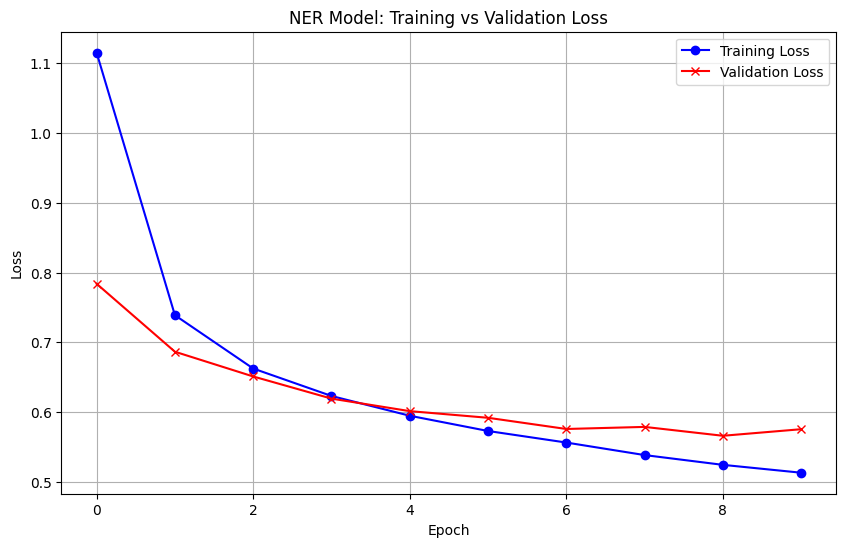

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(val_losses, label='Validation Loss', color='red', marker='x') 

plt.title("NER Model: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

print("TRUE label distribution:")
print(np.bincount(y_test))

print("Actual Test Predictions Distribution:")
print(np.bincount(final_preds))

TRUE label distribution:
[38323  1617  1156  1661   835  1668   257   702   216]
Actual Test Predictions Distribution:
[36345  2374  1276  1865  1042  1891   352   983   307]


## Comparison Between Neural Network and Hidden Markov Model for NER

This section compares the performance of the Feed-Forward Neural Network (using Word2Vec embeddings) and the Hidden Markov Model (HMM) for Named Entity Recognition (NER) using the CoNLL-2003 dataset.

The evaluation is based on Accuracy, Precision, Recall, and F1-score.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison_df = pd.DataFrame({
    "Model": ["Neural Network", "HMM"],
    "Accuracy": [0.8903, 0.9100],
    "Macro F1": [0.6480, 0.6800],
    "Weighted F1": [0.9000, 0.9000]
})

comparison_df

,Model,Accuracy,Macro F1,Weighted F1
0,Neural Network,0.8903,0.648,0.9
1,HMM,0.9100,0.680,0.9


In [ ]:
import pandas as pd

tags = ["B-PER","I-PER","B-ORG","I-ORG","B-LOC","I-LOC","B-MISC","I-MISC","O"]

nn_f1 = [0.68, 0.80, 0.59, 0.51, 0.75, 0.58, 0.48, 0.49, 0.95]
hmm_f1 = [0.49, 0.58, 0.62, 0.66, 0.81, 0.67, 0.66, 0.63, 0.96]

per_class_df = pd.DataFrame({
    "Tag": tags,
    "NN F1": nn_f1,
    "HMM F1": hmm_f1
})

per_class_df

,Tag,NN F1,HMM F1
0,B-PER,0.68,0.49
1,I-PER,0.80,0.58
2,B-ORG,0.59,0.62
3,I-ORG,0.51,0.66
4,B-LOC,0.75,0.81
5,I-LOC,0.58,0.67
6,B-MISC,0.48,0.66
7,I-MISC,0.49,0.63
8,O,0.95,0.96


## Overall Performance Comparison

From the results above, we observe that both models perform well on the NER task, but they differ in how they handle sequential and semantic information.

- The HMM shows slightly higher overall performance in this experiment.
- The Neural Network is expected to generalize better due to the use of word embeddings.

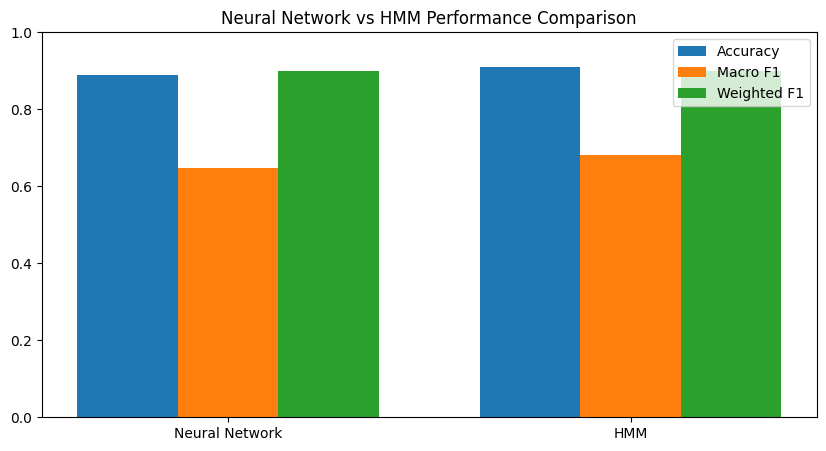

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = comparison_df["Model"]
accuracy = comparison_df["Accuracy"]
macro_f1 = comparison_df["Macro F1"]
weighted_f1 = comparison_df["Weighted F1"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, macro_f1, width, label="Macro F1")
plt.bar(x + width, weighted_f1, width, label="Weighted F1")

plt.xticks(x, models)
plt.ylim(0, 1)
plt.title("Neural Network vs HMM Performance Comparison")
plt.legend()
plt.show()

## Analysis 

The Hidden Markov Model (HMM) achieved slightly higher accuracy and macro F1-score compared to the Neural Network model. This is because HMM explicitly models the sequential dependency between tags using transition probabilities, which is highly effective for structured prediction tasks like Named Entity Recognition.

However, HMM relies heavily on observed word-tag frequencies and does not capture semantic meaning between words. This limits its ability to generalize to unseen or rare words.

On the other hand, the Neural Network model uses Word2Vec embeddings as input, allowing it to capture semantic similarity between words. Although its performance is slightly lower in this experiment, it is generally more robust and scalable for real-world NLP applications.

Overall, HMM is stronger in structured sequence modeling, while Neural Networks provide better representation learning and generalization capability.